In [7]:
import tapas
from tapas.attacks.set_classifiers import RandomTargetedQueryFeature
from utils.basegenerators import Raw
from utils.my_attack import MyAttack
from utils.benchmark_pipeline import BenchmarkPipeline
from utils.benchmark_metric import AUCMetric

from utils.basegenerators import BenchmarkGenerator, ReprosynGenerator, Raw
from utils.tapas.tapas_data_processors import AdultDataProcessor

estimating categorical probs
estimating approx kdes(histogram)
[0.6759398496240602]
Attacking : Raw
Generate datasets
COMPLEXITY:  2
COMPLEXITY:  20


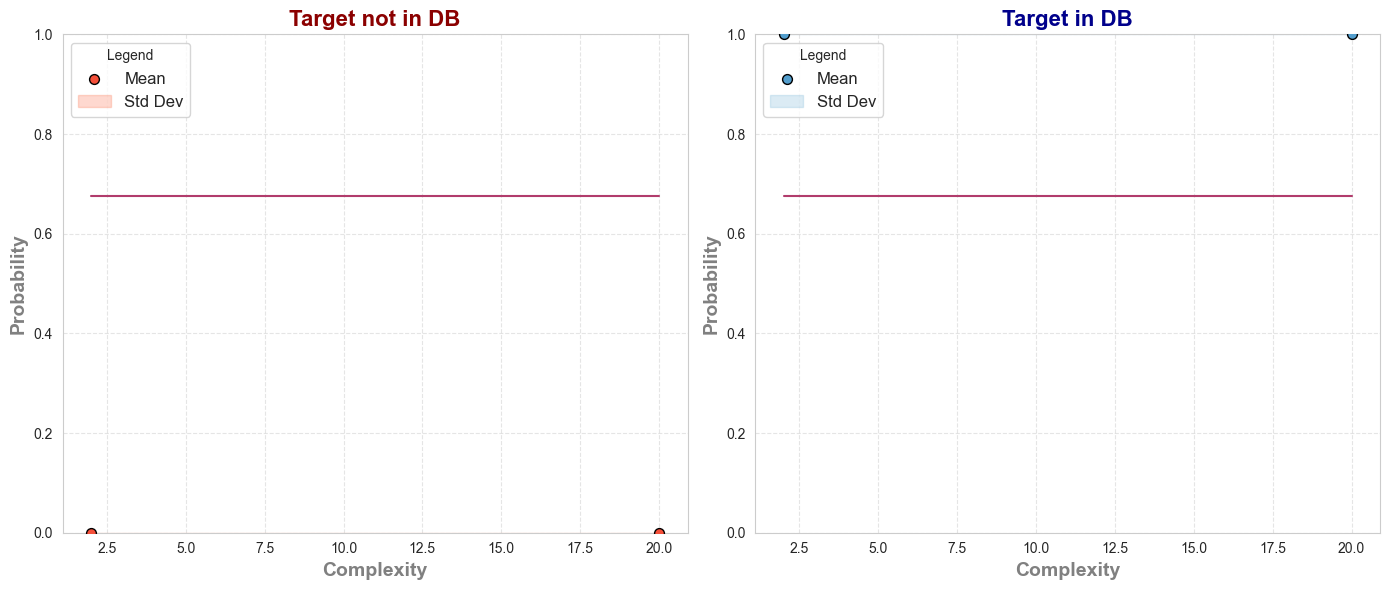

Attacking : PrivBayes_epsilon=10.0
Generate datasets
COMPLEXITY:  2
COMPLEXITY:  20


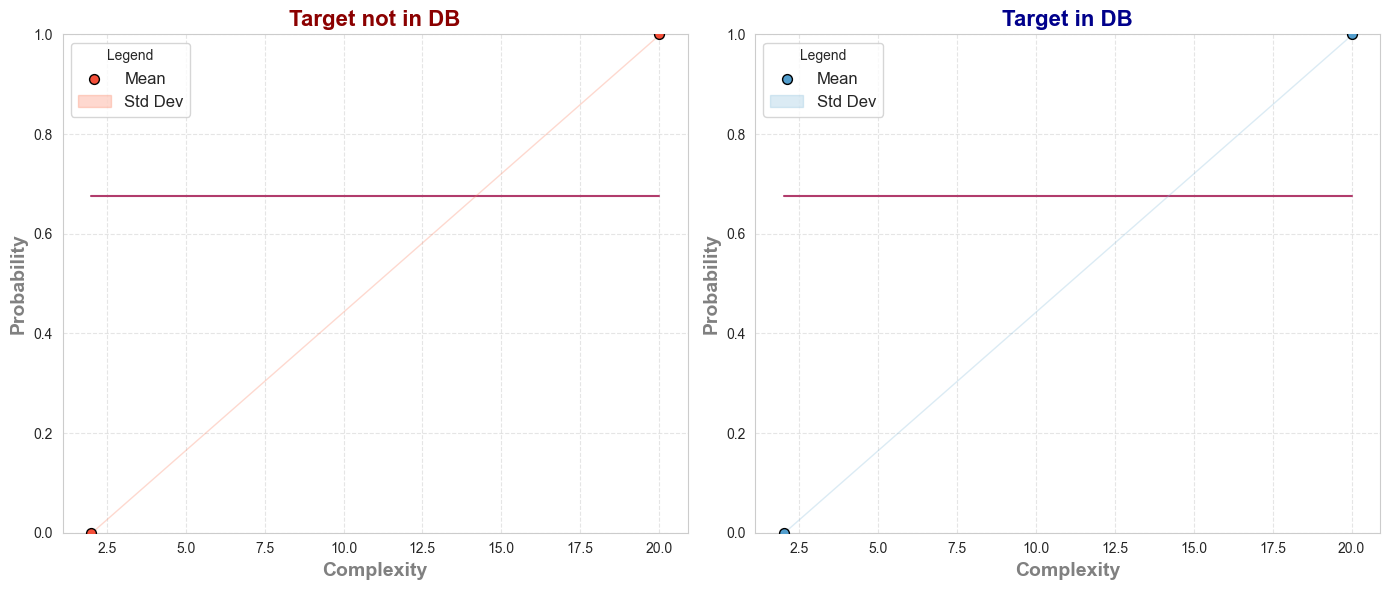

----[Benchmark ranks]----
Raw : F, 1.0
Raw was not broken by the attack
PrivBayes : D, 0.5
PrivBayes was not broken by the attack
Results saved to results_complexity_break.csv


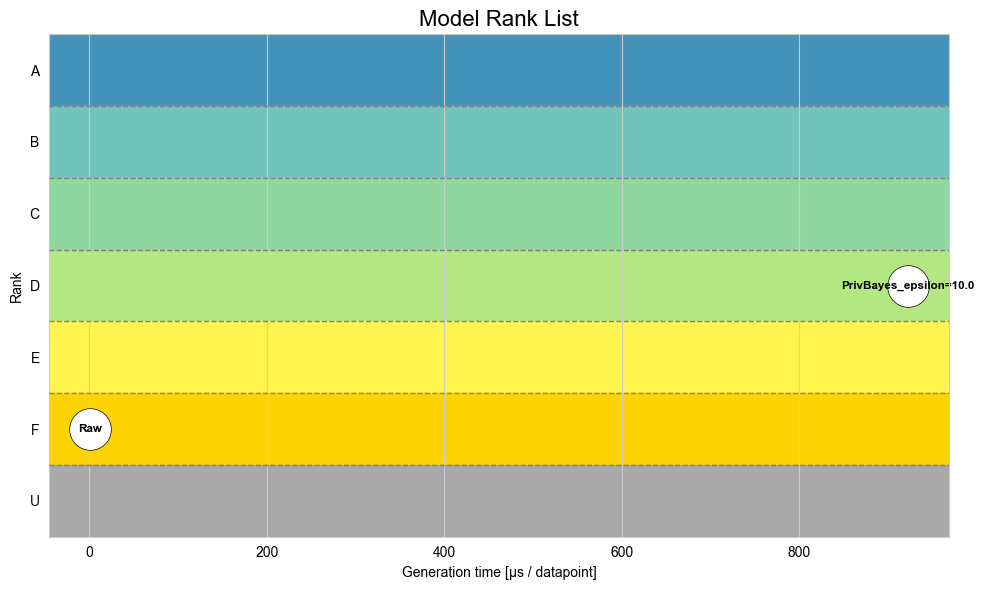

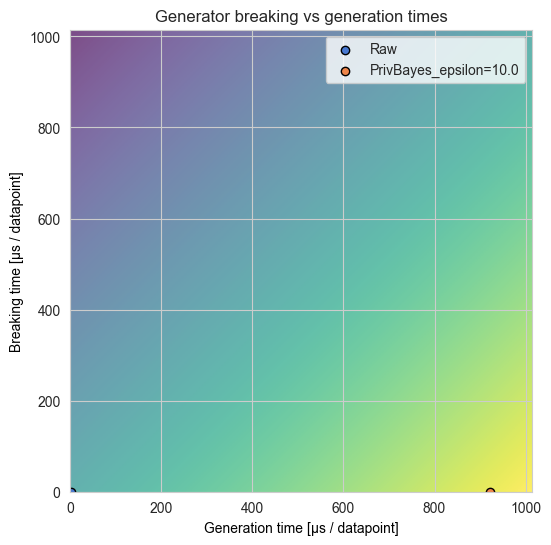

In [8]:
data = tapas.datasets.TabularDataset.read("data/adult")
data = AdultDataProcessor.process_tapas_tabulardataset(data)
target_record = data.get_records([0])
data.drop_records([0], in_place=True)
attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,4,2))

gen = Raw()

pipeline = BenchmarkPipeline(data, attack, [gen], target_record=target_record)
# benchmarking_metric = AUCMetric([0, 0.17, 0.33, 0.5, 0.67, 0.83])


# just add the path to the folder where the generated data will be saved, the name of the file will be generated automatically
pipeline.run([2,20], 1, 2,  plot_style='double', benchmarking_metric=benchmarking_metric)

# if you want to run the attack without generating data, just set generate=False and add the path to the folder where the generated data will be saved
# pipeline.run_importing_data([2,4], 1, 2, imported_data_path="data/shadow_datasets_Raw_4.pkl")

In [3]:
pipeline.ml_utility("income", optimize_hyperparams=False,cat_features=["workclass","education","education-num","marital-status","occupation",
                                                       "relationship","race","sex","native-country","income"])

Number of samples: 45221
Evaluating : PrivBayes_epsilon=1.0
Evaluating original data
95% CI for test score: [0.8600, 0.8745]
Evaluating generated data
Evaluating : PrivBayes_epsilon=10.0
Evaluating generated data
Results saved to results_ml_utility.csv


In [4]:
pipeline.average_dcr(100,metric="gower")

Evaluating : PrivBayes_epsilon=1.0
Using Gower distance


0.1998252

In [70]:
# open csv file with the results as a dataframe
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import minmax_scale

results_complexity_break = pd.read_csv("results_complexity_break.csv")
results_dcr = pd.read_csv("results_dcr.csv")
results_utility = pd.read_csv("results_ml_utility.csv")

results_utility.head()

,generator,dataset,test_score
0,Raw,original,0.702467
1,Raw,generated,0.701550
2,PrivBayes_epsilon=10.0,original,0.702467
3,PrivBayes_epsilon=10.0,generated,0.518401


In [71]:
# normalize the results in complexity_break
max_speed = results_complexity_break["Speed"].max() + 0.05*results_complexity_break["Speed"].max()
min_speed = results_complexity_break["Speed"].min() - 0.05*results_complexity_break["Speed"].min()
results_complexity_break["Speed"] = (results_complexity_break["Speed"] - min_speed) / (max_speed - min_speed)

results_complexity_break["Benchmark_metric"] = 1 - results_complexity_break["Benchmark_metric"]
mask = results_complexity_break['breaking_time'] != -1
bt_min = results_complexity_break.loc[mask, 'breaking_time'].min()
bt_max = results_complexity_break.loc[mask, 'breaking_time'].max()
results_complexity_break.loc[~mask, 'breaking_time'] = bt_max * 1.1

# 3) either overwrite the original column...
results_complexity_break['breaking_time'] = (
    results_complexity_break['breaking_time'] - bt_min
) / (bt_max - bt_min)

results_complexity_break

,Model,Speed,Benchmark_rank,Benchmark_metric,breaking_time
0,Raw,0.000046,F,0.0,NaN
1,PrivBayes_epsilon=10.0,0.952339,D,0.5,NaN


In [72]:


# normalize the results in dcr
results_dcr["dcr_mean"] = minmax_scale(results_dcr["dcr_mean"])
results_dcr.head()

# normalize the results in ml_utility
results_utility = results_utility[results_utility["dataset"] == "generated"]
results_utility["test_score"] = minmax_scale(results_utility["test_score"])
results_utility.head()

# create a new dataframe with columsn names from labels 
labels = ["AUC_MIA","DCR", "ML_Utility", "Time_to_Break","Generation_Time"]
results = pd.DataFrame(columns=labels)
results["AUC_MIA"] = results_complexity_break["Benchmark_metric"]
results["DCR"] = results_dcr["dcr_mean"]
results["ML_Utility"] = results_utility["test_score"]
results["Time_to_Break"] = results_complexity_break["breaking_time"]
results["Generation_Time"] = results_complexity_break["Speed"]
print()
results.head()

,AUC_MIA,DCR,ML_Utility,Time_to_Break,Generation_Time
0,0.0,0.0,NaN,NaN,0.000046
1,0.5,1.0,1.0,NaN,0.952339


In [6]:
# create a spider plot with the results
lables = ["AUC MIA","DCR", "ML Utility", "Complexity Break","Generation Time"]
num_vars = len(lables)


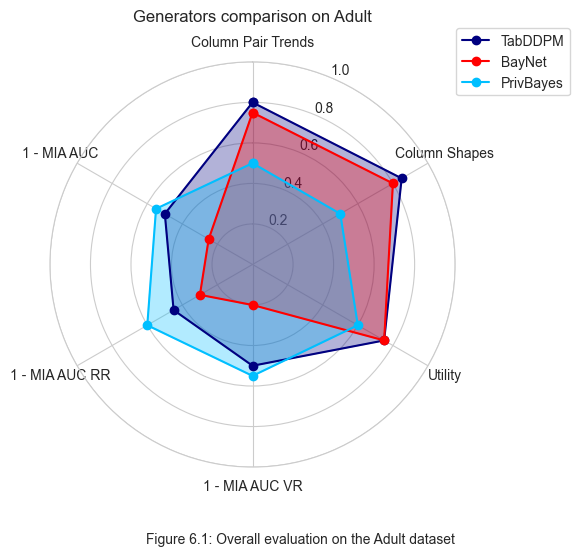

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Define the labels for each axis
labels = ['Column Pair Trends', 'Column Shapes', 'Utility', 
          '1 - MIA AUC VR', '1 - MIA AUC RR', '1 - MIA AUC']
num_vars = len(labels)

# Example data (scaled between 0 and 1)
tabddpm = [0.8, 0.85, 0.75, 0.5, 0.45, 0.5]
baynet = [0.75, 0.8, 0.75, 0.2, 0.3, 0.25]
privbayes = [0.5, 0.5, 0.6, 0.55, 0.6, 0.55]

# Function to close the loop for radar chart
def radar_data(data):
    return data + [data[0]]

tabddpm = radar_data(tabddpm)
baynet = radar_data(baynet)
privbayes = radar_data(privbayes)

# Compute angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the loop

# Initialize radar chart
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

# Plot each model
ax.plot(angles, tabddpm, label='TabDDPM', color='navy', marker='o')
ax.fill(angles, tabddpm, color='navy', alpha=0.3)

ax.plot(angles, baynet, label='BayNet', color='red', marker='o')
ax.fill(angles, baynet, color='red', alpha=0.3)

ax.plot(angles, privbayes, label='PrivBayes', color='deepskyblue', marker='o')
ax.fill(angles, privbayes, color='deepskyblue', alpha=0.3)

# Customize chart
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), labels)  # Use original labels only
ax.set_ylim(0, 1)
ax.set_title('Generators comparison on Adult', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

# Caption
plt.figtext(0.5, 0.01, 'Figure 6.1: Overall evaluation on the Adult dataset', ha='center')

plt.tight_layout()
plt.show()

In [8]:
from typing import Literal
rank_range = [0, 0.17, 0.33, 0.5, 0.67, 0.83]
def compute_rank_from_metric(metric: float) -> float:
    idx = np.searchsorted(rank_range, metric, side='right') - 1
    print(idx)
    rank = 1 #chr(ord('A') + idx)
    return rank

In [9]:
data = tapas.datasets.TabularDataset.read("data/dummy")
target_record = data.get_records([0])
data.drop_records([0], in_place=True)
attack = MyAttack(100, features=RandomTargetedQueryFeature(target_record,2,2))

#gen = ReprosynGenerator(DS_PRIVBAYES, label="PrivBayes", epsilon=1.0)

pipeline = BenchmarkPipeline(data, attack, [Raw()], target_record=target_record)
benchmarking_metric = AUCMetric([0, 0.17, 0.33, 0.5, 0.67, 0.83])

# Function to close the loop for radar chart
def radar_data(data):
    return data + [data[0]]

# just add the path to the folder where the generated data will be saved, the name of the file will be generated automatically
pipeline.run([2,20], 1, 2,  plot_style='double', benchmarking_metric=benchmarking_metric)

# if you want to run the attack without generating data, just set generate=False and add the path to the folder where the generated data will be saved
# pipeline.run_importing_data([2,4], 1, 2, imported_data_path="data/shadow_datasets_Raw_4.pkl")

[2 1 0]


1